In [2]:
!pip install torch transformers scikit-learn pandas numpy matplotlib plotly spacy
!python -m spacy download nl_core_news_sm
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install --upgrade "transformers[torch]"
!pip install tqdm


  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
  Using cached click-8.1.8-py3-none-any.whl.metadata (2.3 kB)
  Using cached numpy-2.2.6-cp311-cp311-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/11.1 MB 8.3 MB/s eta 0:00:02
   -------- ------------------------------- 2.4/11.1 MB 8.4 MB/s eta 0:00:02
   -------- ------------------------------- 2.4/11.1 MB 8.4 MB/s eta 0:00:02
   ------------- -------------------------- 3.7/11.1 MB 4.4 MB/s eta 0:00:02
   ------------------ --------------------- 5.2/11.1 MB 5.1 MB/s eta 0:00:02
   ---------------------- ----------------- 6.3/11.1 MB 5.5 MB/s eta 0:00:01
   -----------

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.3/12.8 MB 6.1 MB/s eta 0:00:02
     ------- -------------------------------- 2.4/12.8 MB 5.6 MB/s eta 0:00:02
     ------------ --------------------------- 3.9/12.8 MB 6.2 MB/s eta 0:00:02
     ------------- -------------------------- 4.2/12.8 MB 6.3 MB/s eta 0:00:02
     ------------- -------------------------- 4.5/12.8 MB 4.3 MB/s eta 0:00:02
     ------------------- -------------------- 6.3/12.8 MB 5.0 MB/s eta 0:00:02
     ----------------------- ---------------- 7.6/12.8 MB 5.1 MB/s eta 0:00:02
     ---------------------------- ----------- 9.2/12.8 MB 5.4 MB/s eta 0:00:01
     ------------------------------- -------- 10.0/12.8 MB 5.4 MB/s eta 0:00:01
     ------------------------------- -------- 10.0/12.8 MB 5.4 MB/s eta 0:00:01
     ----------------------------------- ---- 11.3/12.8 MB 4.9 MB/s eta 0:00:01
     ------------------------------------ --- 11.8/12.8 

In [ ]:
import os
import spacy
import pandas as pd
import pickle
import json
import numpy as np
import openpyxl



# --- Set your model folder here ---
model_folder = "Corex_model_slavery1"  # <--- CHANGE ONLY THIS

# Load topic names and wordlists
with open(os.path.join(model_folder, "lda_topicdata.json"), "r", encoding="utf-8") as f:
    topic_data = json.load(f)
topic_names = topic_data["topic_names"]
topic_word_lists = topic_data["topic_word_lists"]

# Load LDA model
with open(os.path.join(model_folder, "lda_model.pkl"), "rb") as f:
    lda_model = pickle.load(f)

# Load Gensim dictionary
with open(os.path.join(model_folder, "lda_dictionary.pkl"), "rb") as f:
    lda_dictionary = pickle.load(f)

# Load stopwords
with open(os.path.join(model_folder, "lda_stopwords.json"), "r", encoding="utf-8") as f:
    stop_words = set(json.load(f))

# (Optional) Load metadata if needed
meta_path = os.path.join(model_folder, "meta.json")
if os.path.exists(meta_path):
    with open(meta_path, "r", encoding="utf-8") as f:
        meta = json.load(f)
    print(f"Loaded meta info: {meta}")
else:
    meta = None
# Load SpaCy Dutch model for sentence splitting (unchanged)
nlp = spacy.load("nl_core_news_sm")

def split_sentences(text):
    doc = nlp(str(text))
    return [sent.text.strip() for sent in doc.sents]


import re
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

# Setup for tokenization/stemming (adapt as needed)
stemmer = SnowballStemmer('dutch')
stop_words = set(stopwords.words('dutch')) | set(stopwords.words('english'))

def clean_and_tokenize(text):
    # Simple cleaning/tokenizing/stemming
    text = re.sub(r'[^A-Za-zÀ-ÿ0-9 ]', ' ', text.lower())
    tokens = [stemmer.stem(w) for w in text.split() if w not in stop_words and len(w) > 2]
    return tokens

# ----- CHANGED: Replace regex matching by LDA topic assignment -----
def assign_topic_LDA(sentence):
    tokens = clean_and_tokenize(sentence)
    bow = lda_dictionary.doc2bow(tokens)
    topic_probs = lda_model.get_document_topics(bow, minimum_probability=0.0)
    # topic_probs: list of (topic_id, prob) tuples
    if not topic_probs:
        return None, 0.0
    topic_id, prob = max(topic_probs, key=lambda x: x[1])
    # Only assign if confidence is reasonable
    if prob > 0.20:   # You may tweak this threshold!
        return topic_names[topic_id], prob
    else:
        return None, prob

# ----- REPLACEMENT FOR process_folder_sentences_with_highest_priority -----
def process_folder_sentences_with_lda(folder_path):
    results = []
    for fname in sorted(os.listdir(folder_path)):
        if fname.lower().endswith('.txt'):
            with open(os.path.join(folder_path, fname), encoding='utf-8') as f:
                text = f.read()
            for sentence in split_sentences(text):
                topic, confidence = assign_topic_LDA(sentence)
                if topic:
                    results.append({
                        'filename': fname,
                        'clean_text': text,   # Whole file text
                        'sentence': sentence,
                        'topic': topic,
                        'confidence': confidence
                    })
    return pd.DataFrame(results)

# ----- REPLACEMENT FOR process_excel_sentences_with_highest_priority -----
def process_excel_sentences_with_lda(excel_file, text_column='clean_text', id_column='filename'):
    df = pd.read_excel(excel_file)
    if text_column not in df.columns:
        raise ValueError(f"{text_column} not found in {excel_file}")
    results = []
    for idx, row in df.iterrows():
        text = row[text_column]
        filename = row[id_column] if id_column in row else f'row_{idx}'
        for sentence in split_sentences(text):
            topic, confidence = assign_topic_LDA(sentence)
            if topic:
                results.append({
                    'filename': filename,
                    'clean_text': text,
                    'sentence': sentence,
                    'topic': topic,
                    'confidence': confidence
                })
    return pd.DataFrame(results)

# ---- Choose source: Folder or Excel (structure unchanged) ----
use_folder = False
if use_folder:
    folder_with_txts = "sources"
    train_source = process_folder_sentences_with_lda(folder_with_txts)
else:
    excel_file = '2023_selectedtypes_cleaned (1).xlsx'
    train_source = process_excel_sentences_with_lda(excel_file, text_column='clean_text', id_column='filename')

train_source.to_csv('sentence_topic_lda_assignments.csv', index=False, encoding='utf-8')
display(train_source.head(20))

# ----- Topic Counts Visualization (Unchanged) -----
topic_counts = train_source['topic'].value_counts().reset_index()
topic_counts.columns = ['topic', 'count']

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.barh(topic_counts['topic'], topic_counts['count'])
plt.xlabel('Count')
plt.ylabel('Topic')
plt.title('Number of Sentences Assigned per Topic')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Loaded meta info: {'created': '2025-06-30T13:41:47.710533', 'notes': 'Slavery LDA v1; trained on cleaned/stemmed docs; stopwords and dictionary saved; topic-wordlists are stemmed.', 'n_topics': 5}


AttributeError: 'Corex' object has no attribute 'get_document_topics'

In [8]:
import os
import spacy
import pandas as pd
import pickle
import json
import numpy as np
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
import re

# --- Set your model folder here ---
model_folder = "Corex_model_slavery1"

# Load topic names and wordlists
with open(os.path.join(model_folder, "lda_topicdata.json"), "r", encoding="utf-8") as f:
    topic_data = json.load(f)
topic_names = topic_data["topic_names"]
topic_word_lists = topic_data["topic_word_lists"]

# Load CorEx model and vectorizer
with open(os.path.join(model_folder, "corex_model.pkl"), "rb") as f:
    corex_model = pickle.load(f)
with open(os.path.join(model_folder, "corex_vectorizer.pkl"), "rb") as f:
    vectorizer = pickle.load(f)

# Load stopwords
with open(os.path.join(model_folder, "lda_stopwords.json"), "r", encoding="utf-8") as f:
    stop_words = set(json.load(f))

# Load SpaCy Dutch model for sentence splitting
nlp = spacy.load("nl_core_news_sm")
def split_sentences(text):
    doc = nlp(str(text))
    return [sent.text.strip() for sent in doc.sents]

# Setup for tokenization/stemming
stemmer = SnowballStemmer('dutch')
stop_words |= set(stopwords.words('dutch')) | set(stopwords.words('english'))

def clean_and_tokenize(text):
    text = re.sub(r'[^A-Za-zÀ-ÿ0-9 ]', ' ', text.lower())
    tokens = [stemmer.stem(w) for w in text.split() if w not in stop_words and len(w) > 2]
    return tokens

# ----- CorEx assignment -----
def assign_topic_corex(sentence):
    tokens = clean_and_tokenize(sentence)
    if not tokens:
        return None, 0.0
    sent_str = " ".join(tokens)
    X = vectorizer.transform([sent_str])
    topic_probs = corex_model.transform(X)[0]
    best_topic = int(np.argmax(topic_probs))
    confidence = float(topic_probs[best_topic])
    if confidence > 0.20:   # tweak threshold as needed
        return topic_names[best_topic], confidence
    else:
        return None, confidence

# ----- Folder mode with metadata -----
def process_folder_sentences_with_corex(folder_path):
    results = []
    folder_path = os.path.abspath(folder_path)
    for root, dirs, files in os.walk(folder_path):
        for fname in sorted(files):
            if fname.lower().endswith('.txt'):
                file_path = os.path.join(root, fname)
                # Extract metadata from folder structure
                # Example: .../Policyarchive_text/document_type/year/filename/filename.1.txt
                rel = os.path.relpath(file_path, folder_path)
                parts = rel.split(os.sep)
                document_type, year = None, None
                if len(parts) >= 3:
                    document_type = parts[0]
                    year = parts[1]
                with open(file_path, encoding='utf-8') as f:
                    text = f.read()
                for sentence in split_sentences(text):
                    topic, confidence = assign_topic_corex(sentence)
                    if topic:
                        results.append({
                            'filename': fname,
                            'filepath': file_path,
                            'document_type': document_type,
                            'year': year,
                            'sentence': sentence,
                            'topic': topic,
                            'confidence': confidence
                        })
    return pd.DataFrame(results)

# ---- Choose source: Folder or Excel ----
use_folder = True
if use_folder:
    folder_path = "Policyarchive_text"
    train_source = process_folder_sentences_with_corex(folder_path)
else:
    # Excel mode unchanged, for completeness:
    def process_excel_sentences_with_corex(excel_file, text_column='clean_text', id_column='filename'):
        df = pd.read_excel(excel_file)
        if text_column not in df.columns:
            raise ValueError(f"{text_column} not found in {excel_file}")
        results = []
        for idx, row in df.iterrows():
            text = row[text_column]
            filename = row[id_column] if id_column in row else f'row_{idx}'
            for sentence in split_sentences(text):
                topic, confidence = assign_topic_corex(sentence)
                if topic:
                    results.append({
                        'filename': filename,
                        'sentence': sentence,
                        'topic': topic,
                        'confidence': confidence
                    })
        return pd.DataFrame(results)
    excel_file = r"policy-documents\2015_selectedtypes_cleaned (1).xlsx"
    train_source = process_excel_sentences_with_corex(excel_file, text_column='clean_text', id_column='filename')

# Save to CSV and display preview
train_source.to_csv('sentence_topic_corex_assignments.csv', index=False, encoding='utf-8')
display(train_source.head(20))

# ----- Topic Counts Visualization -----
topic_counts = train_source['topic'].value_counts().reset_index()
topic_counts.columns = ['topic', 'count']

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.barh(topic_counts['topic'], topic_counts['count'])
plt.xlabel('Count')
plt.ylabel('Topic')
plt.title('Number of Sentences Assigned per Topic (CorEx)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

,filename,filepath,document_type,year,sentence,topic,confidence
0,ambtsbericht-nigeria-2015-10-08.10.txt,Policyarchive_text\ambtsberichten\2015\ambtsbe...,ambtsberichten,2015,New Nigeria government faces tough economic de...,Dehumanization & Scientific Racism,1.0
1,ambtsbericht-nigeria-2015-10-08.10.txt,Policyarchive_text\ambtsberichten\2015\ambtsbe...,ambtsberichten,2015,strike was warning for shot to new\nleader (27...,Dehumanization & Scientific Racism,1.0
2,ambtsbericht-nigeria-2015-10-08.10.txt,Policyarchive_text\ambtsberichten\2015\ambtsbe...,ambtsberichten,2015,"fuel strike was a warning shot to new leader, ...",Dehumanization & Scientific Racism,1.0
3,ambtsbericht-nigeria-2015-10-08.10.txt,Policyarchive_text\ambtsberichten\2015\ambtsbe...,ambtsberichten,2015,Eerdere pogingen van de voormalige regering om...,Dehumanization & Scientific Racism,1.0
4,ambtsbericht-nigeria-2015-10-08.11.txt,Policyarchive_text\ambtsberichten\2015\ambtsbe...,ambtsberichten,2015,(Chief of Defence\nStaff and Service Chiefs).2...,Dehumanization & Scientific Racism,1.0
5,ambtsbericht-nigeria-2015-10-08.11.txt,Policyarchive_text\ambtsberichten\2015\ambtsbe...,ambtsberichten,2015,In de volksmond\nwerden de burgerwachten ‘Civi...,Dehumanization & Scientific Racism,1.0
6,ambtsbericht-nigeria-2015-10-08.11.txt,Policyarchive_text\ambtsberichten\2015\ambtsbe...,ambtsberichten,2015,Volgens de New York\nTimes werd de zogenaamde ...,Dehumanization & Scientific Racism,1.0
7,ambtsbericht-nigeria-2015-10-08.11.txt,Policyarchive_text\ambtsberichten\2015\ambtsbe...,ambtsberichten,2015,De Joint Task Force is samengesteld uit milita...,Dehumanization & Scientific Racism,1.0
8,ambtsbericht-nigeria-2015-10-08.12.txt,Policyarchive_text\ambtsberichten\2015\ambtsbe...,ambtsberichten,2015,Een adequate tactische training gericht op de\...,Everyday Racism & Modern Racial Inequality,1.0
9,ambtsbericht-nigeria-2015-10-08.14.txt,Policyarchive_text\ambtsberichten\2015\ambtsbe...,ambtsberichten,2015,In januari 2015 blies de African Union Peace a...,Dehumanization & Scientific Racism,1.0


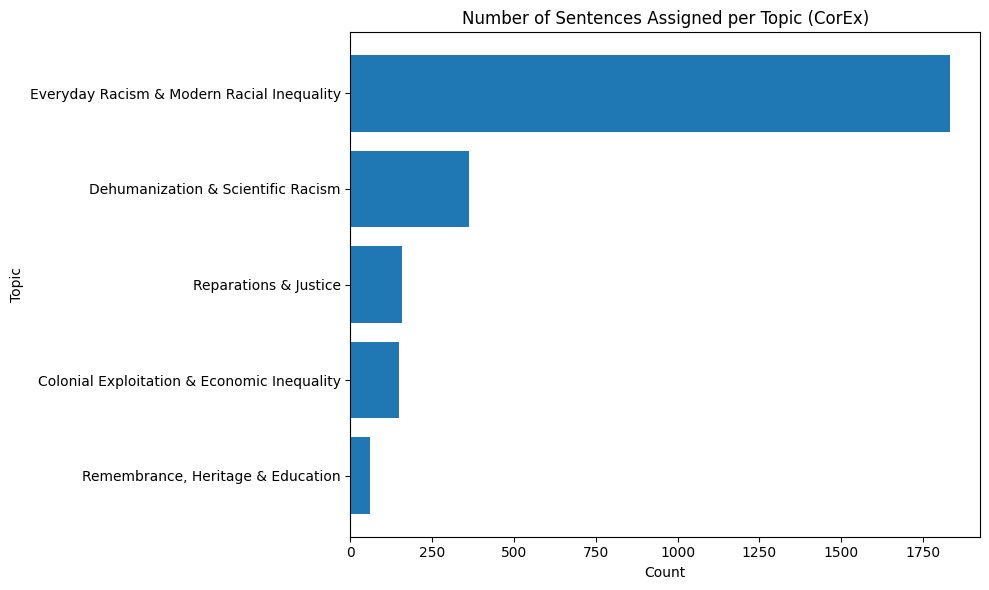

In [ ]:
import os
import spacy
import pandas as pd
import pickle
import json
import numpy as np
import re
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

# --- Set your model folder here ---
model_folder = "Corex_model_slavery1"  # <--- CHANGE ONLY THIS
# ---- Usage Example ----
use_folder = True
SENTS_PER_CHUNK = 5      # Number of sentences per chunk (e.g., 5)
CONFIDENCE_THRESHOLD = 0.40   # Only keep assignments above this probability

if use_folder:
    folder_path = "Policyarchive_text"  # or your folder
    # ---- SET YOUR YEAR FILTER HERE ----
    years_to_include = 2015
    # Example: Range
    # years_to_include = [str(y) for y in range(2010, 2016)]





# ----- Load models and resources -----
with open(os.path.join(model_folder, "lda_topicdata.json"), "r", encoding="utf-8") as f:
    topic_data = json.load(f)
topic_names = topic_data["topic_names"]
topic_word_lists = topic_data["topic_word_lists"]

with open(os.path.join(model_folder, "corex_model.pkl"), "rb") as f:
    corex_model = pickle.load(f)

with open(os.path.join(model_folder, "corex_vectorizer.pkl"), "rb") as f:
    vectorizer = pickle.load(f)

with open(os.path.join(model_folder, "lda_stopwords.json"), "r", encoding="utf-8") as f:
    stop_words = set(json.load(f))

nlp = spacy.load("nl_core_news_sm")
stemmer = SnowballStemmer('dutch')
stop_words = set(stopwords.words('dutch')) | set(stopwords.words('english'))

def split_sentences(text):
    doc = nlp(str(text))
    return [sent.text.strip() for sent in doc.sents]

def clean_and_tokenize(text):
    text = re.sub(r'[^A-Za-zÀ-ÿ0-9 ]', ' ', text.lower())
    tokens = [stemmer.stem(w) for w in text.split() if w not in stop_words and len(w) > 2]
    return tokens

def assign_topic_corex(sentence):
    tokens = clean_and_tokenize(chunk)
    if not tokens:
        return None, 0.0
    sent_str = " ".join(tokens)
    X = vectorizer.transform([sent_str])
    topic_probs = corex_model.transform(X)[0]
    best_topic = int(np.argmax(topic_probs))
    confidence = float(topic_probs[best_topic])
    if confidence > CONFIDENCE_THRESHOLD:
        return topic_names[best_topic], confidence
    else:
        return None, confidence
    


# ----- Main Folder Processor -----
def process_folder_sentences_with_corex(folder_path, years_to_include=None):
    """
    years_to_include: list of str or int, e.g. ['2005','2006'] or [2005,2006], or single str/int
    """
    if years_to_include is not None:
        years_to_include = set(str(y) for y in (years_to_include if isinstance(years_to_include, (list, set)) else [years_to_include]))
    results = []
    for root, dirs, files in os.walk(folder_path):
        for fname in sorted(files):
            if fname.lower().endswith('.txt'):
                file_path = os.path.join(root, fname)
                path_parts = os.path.normpath(file_path).split(os.sep)
                # Try to extract document_type and year
                # Expect: .../folder/document_type/year/filename/filename.1.txt
                try:
                    document_type = path_parts[-4]
                    year = path_parts[-3]
                except IndexError:
                    document_type = None
                    year = None
                # Filter by year
                if years_to_include is not None and year not in years_to_include:
                    continue
                with open(file_path, encoding='utf-8') as f:
                    text = f.read()
                for sentence in split_sentences(text):
                    topic, confidence = assign_topic_corex(sentence)
                    if topic:
                        results.append({
                            'filename': fname,
                            'filepath': file_path,
                            'document_type': document_type,
                            'year': year,
                            'sentence': sentence,
                            'topic': topic,
                            'confidence': confidence
                        })
    return pd.DataFrame(results)

# ---- Usage Example ----
use_folder = True
if use_folder:
    folder_path = "Policyarchive_text"  # or your folder
    # ---- SET YOUR YEAR FILTER HERE ----
    years_to_include = 2015
    # Example: Range
    # years_to_include = [str(y) for y in range(2010, 2016)]

    train_source = process_folder_sentences_with_corex(folder_path, years_to_include=years_to_include)
else:
    excel_file = r"policy-documents\2015_selectedtypes_cleaned (1).xlsx"
    train_source = process_excel_sentences_with_corex(excel_file, text_column='clean_text', id_column='filename')

train_source.to_csv('sentence_topic_corex_assignments.csv', index=False, encoding='utf-8')
display(train_source.head(20))

# ----- Topic Counts Visualization -----
topic_counts = train_source['topic'].value_counts().reset_index()
topic_counts.columns = ['topic', 'count']

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.barh(topic_counts['topic'], topic_counts['count'])
plt.xlabel('Count')
plt.ylabel('Topic')
plt.title('Number of Sentences Assigned per Topic (CorEx)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
import os
import re
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

# ===== USER SETTINGS =====
USE_FOLDER = True  # True = use folder, False = Excel (Excel not included here)
SOURCE_FOLDER_PATH = "Policyarchive_text"
OUTPUT_FOLDER = "Policyarchive/corex_chunk_outputs_2015"
MODEL_FOLDER = "Corex_model_slavery1"
YEAR_FILTER = ('2015', '2016')    # (start, end), both as string (or (None, None) for all)
DOC_TYPES = ["ambtsberichten", "beleidsnotas", "besluiten", "jaarplannen", "jaarverslagen"]  # or [] for all
SENTS_PER_CHUNK = 5
CONFIDENCE_THRESHOLD = 0.40
MIN_COSINE = 0.05

# ========== FILE FINDER (matches your folder structure) ==========
def find_txt_files_by_folder(base_folder, year_filter=None, doc_types=None):
    matches = []
    for root, dirs, files in os.walk(base_folder):
        path_parts = os.path.normpath(root).split(os.sep)
        if len(path_parts) < 3:
            continue
        document_type = path_parts[-3]
        year = path_parts[-2]
        year_ok = True
        type_ok = True
        if year_filter and year_filter[0] is not None:
            year_ok = year.isdigit() and (str(year_filter[0]) <= year <= str(year_filter[1]))
        if doc_types:
            type_ok = document_type.lower() in [dt.lower() for dt in doc_types]
        if not (year_ok and type_ok):
            continue
        for fname in files:
            if fname.lower().endswith('.txt'):
                matches.append(os.path.join(root, fname))
    return matches

# ========== SETTINGS CONFIRMATION ==========
def confirm_and_print_settings(files=None):
    print("\n========= FILTER SETTINGS =========")
    print(f"Source folder:      {SOURCE_FOLDER_PATH}")
    print(f"Output folder:      {OUTPUT_FOLDER}")
    print(f"Year filter:        {YEAR_FILTER}")
    print(f"Doc type filter:    {DOC_TYPES}")
    print(f"Sentences per chunk:{SENTS_PER_CHUNK}")
    print(f"Min confidence:     {CONFIDENCE_THRESHOLD}")
    print(f"Min cosine:         {MIN_COSINE}")
    print(f"Model folder:       {MODEL_FOLDER}")
    print("------------------------------------")
    if files is not None:
        print(f"Found {len(files)} .txt files to process after filtering.")
        preview = files[:10] if len(files) > 10 else files
        print("First files to process:")
        for f in preview:
            print(f"  - {f}")
        if len(files) > 10:
            print("  ...")
    print()

# ========== CHUNK PROCESSING WORKER ==========
def process_file_chunk(
    file_path,
    model_folder,
    sents_per_chunk,
    confidence_threshold,
    min_cosine,
    topic_names,
    topic_word_lists,
):
    import spacy
    from nltk.corpus import stopwords
    from nltk.stem.snowball import SnowballStemmer

    with open(os.path.join(model_folder, "corex_model.pkl"), "rb") as f:
        corex_model = pickle.load(f)
    with open(os.path.join(model_folder, "corex_vectorizer.pkl"), "rb") as f:
        vectorizer = pickle.load(f)
    with open(os.path.join(model_folder, "lda_stopwords.json"), "r", encoding="utf-8") as f:
        custom_stopwords = set(json.load(f))

    nlp = spacy.load("nl_core_news_sm")
    stemmer = SnowballStemmer('dutch')
    stop_words = set(stopwords.words('dutch')) | set(stopwords.words('english')) | custom_stopwords

    def clean_and_tokenize(text):
        text = re.sub(r'[^A-Za-zÀ-ÿ0-9 ]', ' ', text.lower())
        tokens = [stemmer.stem(w) for w in text.split() if w not in stop_words and len(w) > 2]
        return tokens

    def split_sentences(text):
        doc = nlp(str(text))
        return [sent.text.strip() for sent in doc.sents]

    def chunk_by_sentences(sent_list, sents_per_chunk=sents_per_chunk):
        return [' '.join(sent_list[i:i+sents_per_chunk]).strip()
                for i in range(0, len(sent_list), sents_per_chunk) if sent_list[i:i+sents_per_chunk]]

    def compute_cosine_with_anchors(chunk, topic_word_lists, vectorizer):
        chunk_vec = vectorizer.transform([" ".join(clean_and_tokenize(chunk))])
        max_cos = 0
        for anchor_list in topic_word_lists:
            anchor_vec = vectorizer.transform([" ".join(anchor_list)])
            cos = (chunk_vec @ anchor_vec.T).A[0, 0]
            norm = np.linalg.norm(chunk_vec.data) * np.linalg.norm(anchor_vec.data)
            cos = cos / norm if norm != 0 else 0
            if cos > max_cos:
                max_cos = cos
        return max_cos

    def assign_topic_corex(chunk):
        tokens = clean_and_tokenize(chunk)
        if not tokens:
            return None, 0.0
        sent_str = " ".join(tokens)
        X = vectorizer.transform([sent_str])
        topic_probs = corex_model.transform(X)[0]
        best_topic = int(np.argmax(topic_probs))
        confidence = float(topic_probs[best_topic])
        if confidence > confidence_threshold:
            return best_topic, confidence
        else:
            return None, confidence

    path_parts = os.path.normpath(file_path).split(os.sep)
    try:
        document_type = path_parts[-3]
        year = path_parts[-2]
    except IndexError:
        document_type = None
        year = None
    fname = os.path.basename(file_path)
    out_list = []
    with open(file_path, encoding='utf-8') as f:
        text = f.read()
    sents = split_sentences(text)
    chunks = chunk_by_sentences(sents)
    for i, chunk in enumerate(chunks):
        topic_idx, confidence = assign_topic_corex(chunk)
        if topic_idx is not None:
            cosine = compute_cosine_with_anchors(chunk, topic_word_lists, vectorizer)
            if cosine >= min_cosine:
                out_list.append({
                    'filename': fname,
                    'filepath': file_path,
                    'document_type': document_type,
                    'year': year,
                    'chunk_num': i,
                    'chunk_text': chunk,
                    'topic': topic_names[topic_idx],
                    'confidence': confidence,
                    'cosine': cosine
                })
    return out_list

# ========== LOAD TOPIC DATA ==========
def load_topic_data(model_folder):
    with open(os.path.join(model_folder, "lda_topicdata.json"), "r", encoding="utf-8") as f:
        topic_data = json.load(f)
    return topic_data["topic_names"], topic_data["topic_word_lists"]

# ========== MAIN SCRIPT ==========
if __name__ == "__main__":
    topic_names, topic_word_lists = load_topic_data(MODEL_FOLDER)

    # Find files and print settings
    if USE_FOLDER:
        files = find_txt_files_by_folder(SOURCE_FOLDER_PATH, year_filter=YEAR_FILTER, doc_types=DOC_TYPES)
        confirm_and_print_settings(files)
        if len(files) == 0:
            print("No files found that match the filter settings! Exiting.")
            exit()
        confirm = input("Continue? (yes/no): ").strip().lower()
        if not confirm.startswith('y'):
            print("Aborted by user.")
            exit()
        os.makedirs(OUTPUT_FOLDER, exist_ok=True)
    else:
        raise NotImplementedError("Excel mode not implemented in this script.")

    # Multiprocessing for chunk assignment
    jobs = [
        (
            f,
            MODEL_FOLDER,
            SENTS_PER_CHUNK,
            CONFIDENCE_THRESHOLD,
            MIN_COSINE,
            topic_names,
            topic_word_lists,
        )
        for f in files
    ]
    print(f"Processing {len(files)} files...")
    results = []
    with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
        futures = [executor.submit(process_file_chunk, *job) for job in jobs]
        for future in as_completed(futures):
            result = future.result()
            if result:
                results.extend(result)
    if not results:
        print("No results found after processing.")
        exit()
    train_source = pd.DataFrame(results)
    out_path = os.path.join(OUTPUT_FOLDER, 'chunk_topic_corex_assignments.csv')
    train_source.to_csv(out_path, index=False, encoding='utf-8')
    print(f"\nResults saved to {out_path}")
    print(train_source.head(20))

    # Visualization
    if not train_source.empty:
        topic_counts = train_source['topic'].value_counts().reset_index()
        topic_counts.columns = ['topic', 'count']
        plt.figure(figsize=(10,6))
        plt.barh(topic_counts['topic'], topic_counts['count'])
        plt.xlabel('Count')
        plt.ylabel('Topic')
        plt.title(f'Number of Chunks Assigned per Topic (CorEx, chunk size: {SENTS_PER_CHUNK} sentences)')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print("No data to plot.")




========= FILTER SETTINGS =========
Source folder:      Policyarchive_text
Output folder:      Policyarchive\corex_chunk_outputs_2015
Year filter:        (2015, 2016)
Doc type filter:    ['ambtsberichten', 'beleidsnotas', 'besluiten', 'jaarplannen', 'jaarverslagen']
Sentences per chunk:5
Min confidence:     0.4
Min cosine:         0.05
Model folder:       Corex_model_slavery1
------------------------------------
Found 0 .txt files to process after filtering.
First files to process:

No files found that match the filter settings! Exiting.
Aborted by user.
Starting multiprocessing...
No results found after processing.
Results saved to Policyarchive\corex_chunk_outputs_2015\chunk_topic_corex_assignments.csv
Empty DataFrame
Columns: []
Index: []


KeyError: 'topic'

: 

In [1]:
import os
import spacy
import pandas as pd
import pickle
import json
import numpy as np
import openpyxl
import re
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
import matplotlib.pyplot as plt

# ===== USER SETTINGS =====
SENTS_PER_CHUNK = 5      # Number of sentences per chunk (e.g., 5)
CONFIDENCE_THRESHOLD = 0.40   # Only keep assignments above this probability

# ===== MODEL LOADING =====
model_folder = "Corex_model_slavery1"  # <--- CHANGE ONLY THIS

# Load topic names and wordlists
with open(os.path.join(model_folder, "lda_topicdata.json"), "r", encoding="utf-8") as f:
    topic_data = json.load(f)
topic_names = topic_data["topic_names"]
topic_word_lists = topic_data["topic_word_lists"]

# Load CorEx model
with open(os.path.join(model_folder, "corex_model.pkl"), "rb") as f:
    corex_model = pickle.load(f)

# Load fitted vectorizer
with open(os.path.join(model_folder, "corex_vectorizer.pkl"), "rb") as f:
    vectorizer = pickle.load(f)

# Load stopwords
with open(os.path.join(model_folder, "lda_stopwords.json"), "r", encoding="utf-8") as f:
    stop_words = set(json.load(f))

meta_path = os.path.join(model_folder, "meta.json")
if os.path.exists(meta_path):
    with open(meta_path, "r", encoding="utf-8") as f:
        meta = json.load(f)
    print(f"Loaded meta info: {meta}")
else:
    meta = None

# ===== NLP & CLEANING SETUP =====
nlp = spacy.load("nl_core_news_sm")
stemmer = SnowballStemmer('dutch')
stop_words = set(stopwords.words('dutch')) | set(stopwords.words('english')) | stop_words

def clean_and_tokenize(text):
    text = re.sub(r'[^A-Za-zÀ-ÿ0-9 ]', ' ', text.lower())
    tokens = [stemmer.stem(w) for w in text.split() if w not in stop_words and len(w) > 2]
    return tokens

def split_sentences(text):
    doc = nlp(str(text))
    return [sent.text.strip() for sent in doc.sents]

def chunk_by_sentences(sent_list, sents_per_chunk=SENTS_PER_CHUNK):
    """Group a list of sentences into chunks (strings), each of sents_per_chunk sentences."""
    chunks = []
    for i in range(0, len(sent_list), sents_per_chunk):
        chunk = ' '.join(sent_list[i:i+sents_per_chunk]).strip()
        if chunk:
            chunks.append(chunk)
    return chunks

# ----- CorEx assignment -----
def assign_topic_corex(chunk):
    tokens = clean_and_tokenize(chunk)
    if not tokens:
        return None, 0.0
    sent_str = " ".join(tokens)
    X = vectorizer.transform([sent_str])
    topic_probs = corex_model.transform(X)[0]
    best_topic = int(np.argmax(topic_probs))
    confidence = float(topic_probs[best_topic])
    if confidence > CONFIDENCE_THRESHOLD:
        return topic_names[best_topic], confidence
    else:
        return None, confidence

# --- Folder mode ---
def process_folder_chunks_with_corex(folder_path):
    results = []
    for fname in sorted(os.listdir(folder_path)):
        if fname.lower().endswith('.txt'):
            with open(os.path.join(folder_path, fname), encoding='utf-8') as f:
                text = f.read()
            sents = split_sentences(text)
            chunks = chunk_by_sentences(sents, SENTS_PER_CHUNK)
            for i, chunk in enumerate(chunks):
                topic, confidence = assign_topic_corex(chunk)
                if topic:
                    results.append({
                        'filename': fname,
                        'chunk_num': i,
                        'chunk_text': chunk,
                        'topic': topic,
                        'confidence': confidence
                    })
    return pd.DataFrame(results)

# --- Excel mode ---
def process_excel_chunks_with_corex(excel_file, text_column='clean_text', id_column='filename'):
    df = pd.read_excel(excel_file)
    if text_column not in df.columns:
        raise ValueError(f"{text_column} not found in {excel_file}")
    results = []
    for idx, row in df.iterrows():
        text = row[text_column]
        filename = row[id_column] if id_column in row else f'row_{idx}'
        sents = split_sentences(text)
        chunks = chunk_by_sentences(sents, SENTS_PER_CHUNK)
        for i, chunk in enumerate(chunks):
            topic, confidence = assign_topic_corex(chunk)
            if topic:
                results.append({
                    'filename': filename,
                    'chunk_num': i,
                    'chunk_text': chunk,
                    'topic': topic,
                    'confidence': confidence
                })
    return pd.DataFrame(results)

# ---- Choose source: Folder or Excel ----
use_folder = False
if use_folder:
    folder_with_txts = "sources"
    train_source = process_folder_chunks_with_corex(folder_with_txts)
else:
    excel_file = r"policy-documents\2015_selectedtypes_cleaned (1).xlsx"
    train_source = process_excel_chunks_with_corex(excel_file, text_column='clean_text', id_column='filename')

train_source.to_csv('chunk_topic_corex_assignments.csv', index=False, encoding='utf-8')
print(train_source.head(20))

# ----- Topic Counts Visualization -----
topic_counts = train_source['topic'].value_counts().reset_index()
topic_counts.columns = ['topic', 'count']

plt.figure(figsize=(10,6))
plt.barh(topic_counts['topic'], topic_counts['count'])
plt.xlabel('Count')
plt.ylabel('Topic')
plt.title(f'Number of Chunks Assigned per Topic (CorEx, chunk size: {SENTS_PER_CHUNK} sentences)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Loaded meta info: {'created': '2025-06-30T14:09:54.638111', 'notes': 'CorEx v1; trained on cleaned/stemmed docs; stopwords and vectorizer saved; topic-wordlists are stemmed.', 'n_topics': 5}


FileNotFoundError: [Errno 2] No such file or directory: 'policy-documents\\2015_selectedtypes_cleaned (1).xlsx'

In [22]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# === USER: load your labeled DataFrame and topic lists ===
df = train_source  # The DataFrame with columns: chunk_text, topic, filename, ...
topic_names = topic_names # List of topic names, order matches topic_word_lists
topic_word_lists = topic_word_lists # List of lists of anchor/seed words (all stemmed, matching chunk_text processing)

# ========== 1. Average chunk length in 5-letter words ==========
def chunk_length_in_5letter_words(text):
    words = text.split()
    return sum(max(1, len(w)//5) for w in words)  # Each 5 chars = 1 "word"

df['chunk_5w_len'] = df['chunk_text'].apply(chunk_length_in_5letter_words)
print(f"Overall average chunk length (in 5-letter words): {df['chunk_5w_len'].mean():.2f}")

print("\n--- Average chunk length (per topic) ---")
for t in topic_names:
    sub = df[df['topic'] == t]
    avg_len = sub['chunk_5w_len'].mean() if not sub.empty else 0
    print(f"{t:40s}: {avg_len:.2f}")

# ========== 2. Spread over files / Most present file per topic ==========
print("\n--- Chunks per file (overall) ---")
file_counts = df['filename'].value_counts()
print(file_counts.head(10))

print("\n--- Chunks per file (per topic) & Most present file per topic ---")
for t in topic_names:
    sub = df[df['topic'] == t]
    file_counts = sub['filename'].value_counts()
    if not file_counts.empty:
        print(f"\n[{t}] (total: {len(sub)})")
        print(file_counts.head(5))
        print(f"  Most present file: {file_counts.idxmax()} ({file_counts.max()} chunks)")
    else:
        print(f"\n[{t}] No chunks found.")

# ========== 3. Cosine similarity of each chunk to anchor word set (per topic) ==========
print("\n--- Cosine Similarity to Topic Anchors (TF-IDF, per topic) ---")
tfidf = TfidfVectorizer()
topic_anchor_docs = [' '.join(words) for words in topic_word_lists]
topic_anchor_vecs = tfidf.fit_transform(topic_anchor_docs)

avg_sims_per_topic = []
for i, t in enumerate(topic_names):
    sub = df[df['topic'] == t]
    if sub.empty:
        avg_sims_per_topic.append(0)
        print(f"{t:40s}: N/A")
        continue
    chunk_vecs = tfidf.transform(sub['chunk_text'])
    sims = cosine_similarity(chunk_vecs, topic_anchor_vecs[i])
    avg_sim = np.mean(sims)
    avg_sims_per_topic.append(avg_sim)
    print(f"{t:40s}: {avg_sim:.3f}")

# ========== 4. Average number of keywords present (per topic) ==========
print("\n--- Average # Topic Keywords in Chunk (per topic) ---")
def count_topic_keywords(chunk, topic_word_list):
    chunk_tokens = set(chunk.lower().split())
    anchors = set(topic_word_list)
    return len(chunk_tokens & anchors)

for i, t in enumerate(topic_names):
    sub = df[df['topic'] == t]
    if sub.empty:
        print(f"{t:40s}: N/A")
        continue
    avg_kw = sub['chunk_text'].apply(lambda txt: count_topic_keywords(txt, topic_word_lists[i])).mean()
    print(f"{t:40s}: {avg_kw:.2f}")

# (OPTIONAL) Show summary as table:
summary = pd.DataFrame({
    "topic": topic_names,
    "avg_5w_len": [df[df['topic'] == t]['chunk_5w_len'].mean() for t in topic_names],
    "avg_cos_sim": avg_sims_per_topic,
    "avg_keywords": [
        df[df['topic'] == t]['chunk_text'].apply(lambda txt: count_topic_keywords(txt, topic_word_lists[i])).mean()
        for i, t in enumerate(topic_names)
    ],
    "top_file": [
        df[df['topic'] == t]['filename'].value_counts().idxmax() if not df[df['topic'] == t].empty else None
        for t in topic_names
    ],
    "top_file_count": [
        df[df['topic'] == t]['filename'].value_counts().max() if not df[df['topic'] == t].empty else 0
        for t in topic_names
    ],
})
print("\n--- SUMMARY TABLE ---\n", summary)


Overall average chunk length (in 5-letter words): 97.69

--- Average chunk length (per topic) ---
Dehumanization & Scientific Racism      : 47.80
Colonial Exploitation & Economic Inequality: 109.20
Remembrance, Heritage & Education       : 117.15
Reparations & Justice                   : 135.03
Everyday Racism & Modern Racial Inequality: 108.47

--- Chunks per file (overall) ---
filename
lp-v-j-0000008754.pdf                                                                           69
overzicht-van-internationale-aanbevelingen-op-het-gebied-van-mensenrechten.pdf                  49
bijlage-3-documenten-inzake-wob2-deel1.pdf                                                      47
bijlage-3-documenten-inzake-wob2-deel2.pdf                                                      40
evaluatie-samenwerkingsprogramma-s-sona-curacao.pdf                                             33
evaluatie-samenwerkingsprogramma-s-sona-sint-maarten.pdf                                        29
de-staat-van-he

In [ ]:
import os
import spacy
import pandas as pd
import pickle
import json
import numpy as np
import re
import shutil
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from concurrent.futures import ProcessPoolExecutor, as_completed
import matplotlib.pyplot as plt

# ===== USER SETTINGS =====
USE_FOLDER = True  # True: use folder, False: use Excel file
SOURCE_FOLDER_PATH = "Policyarchive_text"
EXCEL_FILE = r"policy-documents\2015_selectedtypes_cleaned (1).xlsx"
OUTPUT_FOLDER = "Policyarchive\corex_chunk_outputs_2015"

YEAR_FILTER = (2015, 2016)         # Set as (None, None) for all years, or (2015, 2017) for 2015-2017
DOC_TYPES = ["ambtsberichten","beleidsnotas","besluiten","jaarplannen","jaarverslagen"]       # e.g., ["ambtsbericht", "nota"] or [] for all
SENTS_PER_CHUNK = 5               # Sentences per chunk
CONFIDENCE_THRESHOLD = 0.40       # Min CorEx probability to keep chunk
MIN_COSINE = 0.05                 # Min cosine similarity to anchor words (set 0 to disable)

# ===== MODEL LOADING =====
model_folder = "Corex_model_slavery1"

with open(os.path.join(model_folder, "lda_topicdata.json"), "r", encoding="utf-8") as f:
    topic_data = json.load(f)
topic_names = topic_data["topic_names"]
topic_word_lists = topic_data["topic_word_lists"]

with open(os.path.join(model_folder, "corex_model.pkl"), "rb") as f:
    corex_model = pickle.load(f)

with open(os.path.join(model_folder, "corex_vectorizer.pkl"), "rb") as f:
    vectorizer = pickle.load(f)

with open(os.path.join(model_folder, "lda_stopwords.json"), "r", encoding="utf-8") as f:
    stop_words = set(json.load(f))

meta_path = os.path.join(model_folder, "meta.json")
if os.path.exists(meta_path):
    with open(meta_path, "r", encoding="utf-8") as f:
        meta = json.load(f)
    print(f"Loaded meta info: {meta}")
else:
    meta = None

# ===== NLP & CLEANING SETUP =====
nlp = spacy.load("nl_core_news_sm")
stemmer = SnowballStemmer('dutch')
stop_words = set(stopwords.words('dutch')) | set(stopwords.words('english')) | stop_words

def clean_and_tokenize(text):
    text = re.sub(r'[^A-Za-zÀ-ÿ0-9 ]', ' ', text.lower())
    tokens = [stemmer.stem(w) for w in text.split() if w not in stop_words and len(w) > 2]
    return tokens

def split_sentences(text):
    doc = nlp(str(text))
    return [sent.text.strip() for sent in doc.sents]

def chunk_by_sentences(sent_list, sents_per_chunk=SENTS_PER_CHUNK):
    chunks = []
    for i in range(0, len(sent_list), sents_per_chunk):
        chunk = ' '.join(sent_list[i:i+sents_per_chunk]).strip()
        if chunk:
            chunks.append(chunk)
    return chunks

def compute_cosine_with_anchors(chunk, topic_word_lists, vectorizer):
    """Compute max cosine similarity between chunk and any topic anchor list."""
    chunk_vec = vectorizer.transform([" ".join(clean_and_tokenize(chunk))])
    max_cos = 0
    for anchor_list in topic_word_lists:
        anchor_vec = vectorizer.transform([" ".join(anchor_list)])
        cos = (chunk_vec @ anchor_vec.T).A[0, 0]
        norm = np.linalg.norm(chunk_vec.data) * np.linalg.norm(anchor_vec.data)
        if norm != 0:
            cos /= norm
        else:
            cos = 0
        if cos > max_cos:
            max_cos = cos
    return max_cos

def assign_topic_corex(chunk):
    tokens = clean_and_tokenize(chunk)
    if not tokens:
        return None, 0.0
    sent_str = " ".join(tokens)
    X = vectorizer.transform([sent_str])
    topic_probs = corex_model.transform(X)[0]
    best_topic = int(np.argmax(topic_probs))
    confidence = float(topic_probs[best_topic])
    if confidence > CONFIDENCE_THRESHOLD:
        return topic_names[best_topic], confidence
    else:
        return None, confidence

def file_matches(fname, year_range, doc_types):
    # Extract year
    year_match = re.search(r'(\d{4})', fname)
    year_ok = True
    if year_match and year_range[0] is not None:
        year = int(year_match.group(1))
        year_ok = (year_range[0] <= year <= year_range[1])
    type_ok = True
    if doc_types:
        type_ok = any(typ.lower() in fname.lower() for typ in doc_types)
    return year_ok and type_ok

def process_file_chunk(args):
    fname, folder, topic_word_lists, vectorizer = args
    out_list = []
    with open(os.path.join(folder, fname), encoding='utf-8') as f:
        text = f.read()
    sents = split_sentences(text)
    chunks = chunk_by_sentences(sents, SENTS_PER_CHUNK)
    for i, chunk in enumerate(chunks):
        topic, confidence = assign_topic_corex(chunk)
        if topic:
            cosine = compute_cosine_with_anchors(chunk, topic_word_lists, vectorizer)
            if cosine >= MIN_COSINE:
                out_list.append({
                    'filename': fname,
                    'chunk_num': i,
                    'chunk_text': chunk,
                    'topic': topic,
                    'confidence': confidence,
                    'cosine': cosine
                })
    return out_list

# ===== OUTPUT FOLDER CREATION =====
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ====== FILE LISTING & CONFIRMATION ======
if USE_FOLDER:
    files = [f for f in os.listdir(SOURCE_FOLDER_PATH) if f.lower().endswith('.txt')]
    filtered_files = [f for f in files if file_matches(f, YEAR_FILTER, DOC_TYPES)]
    print("========= FILTER SETTINGS =========")
    print(f"Source folder:      {SOURCE_FOLDER_PATH}")
    print(f"Output folder:      {OUTPUT_FOLDER}")
    print(f"Year filter:        {YEAR_FILTER}")
    print(f"Doc type filter:    {DOC_TYPES if DOC_TYPES else 'All'}")
    print(f"Sentences per chunk:{SENTS_PER_CHUNK}")
    print(f"Min confidence:     {CONFIDENCE_THRESHOLD}")
    print(f"Min cosine:         {MIN_COSINE}")
    print(f"Model folder:       {model_folder}")
    print("------------------------------------")
    print(f"Found {len(filtered_files)} .txt files to process after filtering.")
    if len(filtered_files) == 0:
        print("No files found that match the filter settings! Exiting.")
        exit()
    proceed = input("Proceed? Type 'yes' to continue: ")
    if proceed.lower() != "yes":
        print("Aborted by user.")
        exit()
    # Now proceed with filtered_files after confirmation!
    files = filtered_files

    # Multiprocessing
    jobs = [(fname, SOURCE_FOLDER_PATH, topic_word_lists, vectorizer) for fname in files]
    results = []
    with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
        for future in as_completed([executor.submit(process_file_chunk, j) for j in jobs]):
            result = future.result()
            if result:
                results.extend(result)
    train_source = pd.DataFrame(results)
else:
    print("========= FILTER SETTINGS =========")
    print(f"Excel file:         {EXCEL_FILE}")
    print(f"Output folder:      {OUTPUT_FOLDER}")
    print(f"Sentences per chunk:{SENTS_PER_CHUNK}")
    print(f"Min confidence:     {CONFIDENCE_THRESHOLD}")
    print(f"Min cosine:         {MIN_COSINE}")
    print(f"Model folder:       {model_folder}")
    print("------------------------------------")
    proceed = input("Proceed? Type 'yes' to continue: ")
    if proceed.lower() != "yes":
        print("Aborted by user.")
        exit()
    df = pd.read_excel(EXCEL_FILE)
    results = []
    for idx, row in df.iterrows():
        text = row["clean_text"]
        filename = row["filename"] if "filename" in row else f'row_{idx}'
        sents = split_sentences(text)
        chunks = chunk_by_sentences(sents, SENTS_PER_CHUNK)
        for i, chunk in enumerate(chunks):
            topic, confidence = assign_topic_corex(chunk)
            if topic:
                cosine = compute_cosine_with_anchors(chunk, topic_word_lists, vectorizer)
                if cosine >= MIN_COSINE:
                    results.append({
                        'filename': filename,
                        'chunk_num': i,
                        'chunk_text': chunk,
                        'topic': topic,
                        'confidence': confidence,
                        'cosine': cosine
                    })
    train_source = pd.DataFrame(results)

# ===== SAVE RESULTS =====
out_path = os.path.join(OUTPUT_FOLDER, 'chunk_topic_corex_assignments.csv')
train_source.to_csv(out_path, index=False, encoding='utf-8')
print(f"Results saved to {out_path}")
print(train_source.head(20))

# ===== PLOT =====
topic_counts = train_source['topic'].value_counts().reset_index()
topic_counts.columns = ['topic', 'count']

plt.figure(figsize=(10,6))
plt.barh(topic_counts['topic'], topic_counts['count'])
plt.xlabel('Count')
plt.ylabel('Topic')
plt.title(f'Number of Chunks Assigned per Topic (CorEx, chunk size: {SENTS_PER_CHUNK} sentences)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Loaded meta info: {'created': '2025-06-30T14:09:54.638111', 'notes': 'CorEx v1; trained on cleaned/stemmed docs; stopwords and vectorizer saved; topic-wordlists are stemmed.', 'n_topics': 5}
========= FILTER SETTINGS =========
Source folder:      Policyarchive_text
Output folder:      Policyarchive\corex_chunk_outputs_2015
Year filter:        (2015, 2016)
Doc type filter:    ['ambtsberichten', 'beleidsnotas', 'besluiten', 'jaarplannen', 'jaarverslagen']
Sentences per chunk:5
Min confidence:     0.4
Min cosine:         0.05
Model folder:       Corex_model_slavery1
------------------------------------
Found 0 .txt files to process after filtering.
No files found that match the filter settings! Exiting.
Aborted by user.
Results saved to Policyarchive\corex_chunk_outputs_2015\chunk_topic_corex_assignments.csv
Empty DataFrame
Columns: []
Index: []


KeyError: 'topic'

: 

In [40]:
#Step 1: Get Vector Representations
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# If you haven't already, ensure you use a TfidfVectorizer:
vectorizer = TfidfVectorizer(
    stop_words=list(stop_words),
    lowercase=True,
    token_pattern=r'\b\w+\b'
)
# Fit on all chunks (if not already fit)
all_chunk_str = [" ".join(clean_and_tokenize(chunk)) for chunk in train_source['chunk_text']]
X = vectorizer.fit_transform(all_chunk_str)

# Create anchor pseudo-docs
anchor_docs = [" ".join(words) for words in topic_word_lists]
anchor_vecs = vectorizer.transform(anchor_docs)
# Step 2: Calculate Cosine Similarity

# Assign topic index to each row for easy lookup
topic_name_to_idx = {name: i for i, name in enumerate(topic_names)}
topic_idxs = train_source['topic'].map(topic_name_to_idx).values

cosines = []
for idx, row in train_source.iterrows():
    chunk_vec = X[idx]
    topic_idx = topic_name_to_idx[row['topic']]
    anchor_vec = anchor_vecs[topic_idx]
    cos_sim = cosine_similarity(chunk_vec, anchor_vec)[0, 0]
    cosines.append(cos_sim)

train_source['cosine_similarity'] = cosines

# Set your threshold, e.g. 0.15 or top N per topic
cosine_threshold = 0.03

filtered = train_source[train_source['cosine_similarity'] > cosine_threshold]

# Optionally, show top 10 per topic
topN_per_topic = filtered.groupby('topic').apply(lambda df: df.nlargest(10, 'cosine_similarity'))

filtered.to_csv('filtered_high_cosine_chunks.csv', index=False)
display(filtered.head())
display(filtered.groupby('topic').size())



c:\Users\Home\policy-analysis\.conda\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['eilanden'] not in stop_words.
  warnings.warn(
C:\Users\Home\AppData\Local\Temp\ipykernel_29688\1468241271.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  topN_per_topic = filtered.groupby('topic').apply(lambda df: df.nlargest(10, 'cosine_similarity'))


,filename,chunk_num,chunk_text,topic,confidence,chunk_5w_len,cosine_similarity
0,mariene-strategie-voor-het-nederlandse-deel-va...,22,De uropese kaderrichtlijn Mariene Strategie (K...,Everyday Racism & Modern Racial Inequality,1.0,114,0.033248
1,mariene-strategie-voor-het-nederlandse-deel-va...,33,Binnen de kaders van IMO en GVB zet het kabine...,Everyday Racism & Modern Racial Inequality,1.0,156,0.031638
6,mariene-strategie-voor-het-nederlandse-deel-va...,61,De U-Richtlijn voor duurzaam gebruik van pesti...,Everyday Racism & Modern Racial Inequality,1.0,126,0.032061
9,lp-v-j-0000007648.pdf,8,"Het strafrecht is, waar het gaat om de aanpak ...",Everyday Racism & Modern Racial Inequality,1.0,160,0.031891
11,lp-v-j-0000007648.pdf,12,In het kader van de totstandkoming van de wijz...,Reparations & Justice,1.0,176,0.048550


topic
Colonial Exploitation & Economic Inequality     20
Dehumanization & Scientific Racism             166
Everyday Racism & Modern Racial Inequality     231
Remembrance, Heritage & Education               40
Reparations & Justice                           60
dtype: int64

In [27]:
# Set your minimum cosine similarity threshold
COSINE_THRESHOLD = 0.04  # Adjust this value as needed

# Filter the DataFrame
filtered_df = df[df[sims] >= COSINE_THRESHOLD].copy()

print(f"Kept {len(filtered_df)} chunks out of {len(df)} (threshold: {COSINE_THRESHOLD})")
display(filtered_df.head())

# If you want to see distribution per topic
print(filtered_df['topic'].value_counts())

# Optionally, save for use in BERTje or other models
filtered_df.to_csv('filtered_high_cosine_chunks.csv', index=False, encoding='utf-8')


KeyError: "None of [Index([ (0.05002183203581432,), (0.013873560022905832,),\n                        (0.0,), (0.017685388319949397,),\n        (0.06126398224347508,),  (0.03537077663989879,),\n        (0.03537077663989879,),  (0.07279245778961214,),\n        (0.03334788802387621,),                  (0.0,),\n       ...\n        (0.04474088671646301,),  (0.06669577604775243,),\n                        (0.0,),  (0.04474088671646301,),\n        (0.05776023638247129,),  (0.06002619844297718,),\n        (0.04716103551986506,),  (0.05305616495984819,),\n                        (0.0,),                  (0.0,)],\n      dtype='object', length=1008)] are in the [columns]"

In [28]:
print(df.columns)


Index(['filename', 'chunk_num', 'chunk_text', 'topic', 'confidence',
       'chunk_5w_len'],
      dtype='object')


In [ ]:

import re

from nltk.corpus import stopwords

# Get Dutch and English stopwords from NLTK
nltk_stopwords = set(stopwords.words('dutch')) | set(stopwords.words('english'))

# Your custom stopwords (from above, you can paste the long list here)
custom_stopwords = set([# General connectors & prepositions
    "de", "het", "een", "en", "van", "in", "op", "met", "voor", "tegen", "zonder", "bij",
    "naar", "tot", "uit", "door", "aan", "om", "te", "als", "ook", "maar", "want", "dus",
    "of", "dan", "nog", "wel", "zijn", "is", "was", "waren", "worden", "hebben", "heeft", "had",
    "doet", "doen", "al", "alle", "meer", "minder", "veel", "weinig", "binnen", "buiten",
    "tussen", "onder", "boven", "over", "na", "voor", "achter", "naast", "sinds", "tijdens", "zoals",

    # Pronouns & common references
    "ik", "jij", "hij", "zij", "wij", "jullie", "u", "je", "ze", "dit", "dat", "die", "deze", "welke",
    "ons", "hun", "hem", "haar", "ons", "onszelf", "hunzelf", "jouw", "mijn", "jullie",

    # Common report/metadata words seen in clouds
    "bijlage", "bijlagen", "inleiding", "samenvatting", "conclusie", "conclusies", "tabel",
    "groep", "project", "organisatie", "onderdeel", "onderzoek", "overzicht", "resultaten", "resultaat",
    "aantal", "totaal", "deel", "delen", "vraag", "vragen", "antwoord", "antwoorden", "rapport", "rapportage", "toelichting",
    "nullmeting", "nulmeting", "meeting", "metingen", "maatregel", "maatregelen", "jaar", "jaren",
    "gegeven", "gegevens", "gebruik", "gebruikt", "onderwijs", "beleid", "beleidsterrein", "beleidsveld", "beleidsnota",
    "onderzoek", "onderzoeken", "onderzoeker", "onderzoekers", "onderzoeksmethoden",
    "case", "cases", "onderwerpen", "onderwerp", "uitkomst", "uitkomsten", "projecten", "projectgroep", "projectleider",
    "toezicht", "inspectie", "inspecties", "toelichting", "leeswijzer", "artikel", "artikelen", "bijdrage", "doel", "doelen",

    # Government and organization-specific
    "ministerie", "minister", "ministers", "bz", "bzkt", "bzkr", "bzks", "bz", "kw", "kwb", "saba", "bonaire",
    "statia", "statian", "statiae", "statians", "eustatius", "st", "sint", "cn", "bes", "bes-eilanden", "bes eilanden",
    "caribisch", "caribische", "nederland", "nederlandse", "rijksoverheid", "overheid", "publiek", "publieke",
    "inspectie", "audit", "audits", "commissie", "commissies", "toezicht", "burgerrechten", "veiligheid", "politie",
    "samenvatting", "overzicht", "tabel", "tabellen", "bijlage", "bijlagen",

    # Document workflow
    "bijlage", "bijlagen", "blz", "pagina", "paginas", "pagina’s", "hoofdstuk", "hoofdstukken", "paragraaf", "paragrafen",
    "figuur", "figuren", "schema", "schema’s", "grafiek", "grafieken", "afbeelding", "afbeeldingen",

    # Common non-content words from clouds
    "niet", "wel", "geen", "wordt", "worden", "zijn", "is", "was", "zal", "kunnen", "kun", "moet", "moeten",
    "mag", "mogen", "dient", "dienen", "blijft", "blijven", "heeft", "hebben", "kan", "kunnen", "alleen", "samen", "tijdens",

    # Months, dates
    "januari", "februari", "maart", "april", "mei", "juni", "juli", "augustus", "september", "oktober", "november", "december",

    # Miscellaneous observed
    "bijlage", "b", "c", "d", "e", "f", "g", "h", "i", "j", "k", "l", "m", "n", "o", "p", "q", "r", "s", "t", "u", "v", "w", "x", "y", "z", "t", "st",
    "overzicht", "samenvatting", "bijlage", "bijlagen"
])

# Combine them
all_stopwords = nltk_stopwords | custom_stopwords



def remove_stopwords_and_numbers(text, custom_stopwords):
    if pd.isna(text):
        return ""
    # Tokenize words, remove numbers and stopwords, join back to string
    tokens = re.findall(r'\b\w+\b', text.lower())
    filtered = [tok for tok in tokens if tok not in custom_stopwords and not tok.isdigit()]
    return ' '.join(filtered)

train_source['clean_no_stop'] = train_source['clean_text'].apply(lambda x: remove_stopwords_and_numbers(x, custom_stopwords))

display(train_source)

,filename,clean_text,sentence,topic,matched_keyword,clean_no_stop
0,beslisnota-bij-kamerbrief-overzicht-bijzondere...,Aan Staatssecretaris BZK Van DGKR TR ONDRTKNIN...,Overzicht bijzondere uitkeringen,sociale zaken,\bUITKERING(s|\'s|en|-?\w*)?\b,staatssecretaris bzk dgkr tr ondrtkning nota a...
1,beslisnota-bij-kamerbrief-overzicht-bijzondere...,Aan Staatssecretaris BZK Van DGKR TR ONDRTKNIN...,Aanleiding Op grond van artikel 94 van de Wet ...,sociale zaken,\bUITKERING(s|\'s|en|-?\w*)?\b,staatssecretaris bzk dgkr tr ondrtkning nota a...
2,beslisnota-bij-kamerbrief-overzicht-bijzondere...,Aan Staatssecretaris BZK Van DGKR TR ONDRTKNIN...,Dit onder voorwaarden en in de vorm van een bi...,sociale zaken,\bUITKERING(s|\'s|en|-?\w*)?\b,staatssecretaris bzk dgkr tr ondrtkning nota a...
3,beslisnota-bij-kamerbrief-overzicht-bijzondere...,Aan Staatssecretaris BZK Van DGKR TR ONDRTKNIN...,"Voor bijzondere uitkeringen geldt, in tegenste...",sociale zaken,\bUITKERING(s|\'s|en|-?\w*)?\b,staatssecretaris bzk dgkr tr ondrtkning nota a...
4,beslisnota-bij-kamerbrief-overzicht-bijzondere...,Aan Staatssecretaris BZK Van DGKR TR ONDRTKNIN...,In de bijlage bij de Kamerbrief is het overzic...,sociale zaken,\bUITKERING(s|\'s|en|-?\w*)?\b,staatssecretaris bzk dgkr tr ondrtkning nota a...
...,...,...,...,...,...,...
10078,bijlage-2-memorie-van-toelichting-wetsvoorstel...,Versie pre-consultatie 18 januari 2023 1 Bijla...,In de memorie van toelichting bij de eerste tr...,arbeid,\bWERK(s|\'s|en|-?\w*)?\b,versie pre consultatie memorie wetsvoorstel we...
10079,bijlage-2-memorie-van-toelichting-wetsvoorstel...,Versie pre-consultatie 18 januari 2023 1 Bijla...,Het rechtszekerheidsbeginsel en het legaliteit...,arbeid,\bWERK(s|\'s|en|-?\w*)?\b,versie pre consultatie memorie wetsvoorstel we...
10080,bijlage-2-memorie-van-toelichting-wetsvoorstel...,Versie pre-consultatie 18 januari 2023 1 Bijla...,Zonder bekendmaking kan een besluit in het geh...,arbeid,\bWERK(s|\'s|en|-?\w*)?\b,versie pre consultatie memorie wetsvoorstel we...
10081,bijlage-2-memorie-van-toelichting-wetsvoorstel...,Versie pre-consultatie 18 januari 2023 1 Bijla...,Dit geldt bijvoorbeeld voor het vertrouwensbeg...,burgerrechten,\bGELIJKHEID(s|\'s|en|-?\w*)?\b,versie pre consultatie memorie wetsvoorstel we...


In [ ]:
#outdated
from tqdm import tqdm

#topic_counts_df = pd.DataFrame(data=[], index=slavery_df.rows, columns=slavery_df.columns)
topic_counts_list = defaultdict()
matched_sentences = []
multi_topic_sentences = []

for i, row in tqdm(train_source.iterrows(), total=len(train_source), desc="Matching Topics"):

    topic_counts_dict = defaultdict(int)

    text = row['clean_no_stop']
    filename = row['filename'] if 'filename' in row else f'doc_{i}'
    if not pd.isna(text) and text.strip():
        # Collect matching sentences for inspection
        for sent in split_sentences(text):
            if len(sent.split()) < 5:
                continue

            topic_match_counts = defaultdict(int)
            tokens = re.findall(r'\w+', sent, re.UNICODE)
            for token in tokens:
                for regex, topic in compiled_patterns:
                    if regex.fullmatch(token):
                        topic_match_counts[topic] += 1
            if len(topic_match_counts) == 1:
                topic, count = next(iter(topic_match_counts.items()))
                if count >= 2:
                    matched_sentences.append({'sentence': sent.strip(), 'topic': topic, 'document': filename})
                    topic_counts_dict[topic] += 1
                else:
                    matched_sentences.append({'sentence': sent.strip(), 'topic': 'not-matched', 'document': filename})
            else:
                if len(topic_match_counts) > 1:
                    multi_topic_sentences.append(sent.strip())
                    matched_sentences.append({'sentence': sent.strip(), 'topic': 'not-matched', 'document': filename})

        topic_counts_list[filename] = topic_counts_dict



display(multi_topic_sentences)

# Topic counts per document
#display(topic_counts_list)
#counts_df = pd.concat([slavery_df.reset_index(drop=True), topic_counts_list], axis=1)

# Save to CSV
#counts_df.to_csv('topic_counts_per_document.csv', index=False)
#display(counts_df.head())


# (Optional) Export matched sentences for review
matched_df = pd.DataFrame(matched_sentences)
matched_df.to_csv('slavery-regex-matched_sentences.csv', index=False)
#matched_df.to_csv('policy-regex-matched_sentences.csv', index=False)

display(matched_df.head())

print("✅ Topic matching completed.")


NameError: name 'defaultdict' is not defined

In [12]:
from sklearn.preprocessing import LabelEncoder

# Assume 'train_source' has a column 'topic'
le = LabelEncoder()
train_source['label'] = le.fit_transform(train_source['topic'])
label2topic = dict(zip(train_source['label'], train_source['topic']))
print(label2topic)

from collections import Counter

# Count class frequencies
label_counts = train_source['label'].value_counts()

# Find classes with only 1 example
singleton_labels = label_counts[label_counts == 1].index.tolist()

# Show the removed classes and their topic names
print("The following topic classes have only one example and will be removed:")
for lbl in singleton_labels:
    topic_name = le.inverse_transform([lbl])[0]
    print(f"  Label: {lbl}, Topic: '{topic_name}'")

# Remove singleton classes from the DataFrame
filtered_df = train_source[~train_source['label'].isin(singleton_labels)].copy()
print(f"\nKept {len(filtered_df)} sentences across {filtered_df['label'].nunique()} topics.")
filtered_df.to_csv('filtered_topic_matches.csv', index=False)


{8: 'sociale zaken', 3: 'criminaliteit', 1: 'arbeid', 7: 'religie', 6: 'onderwijs', 5: 'immigratie', 4: 'gezondheidszorg', 2: 'burgerrechten', 0: 'Cultuur en sport'}
The following topic classes have only one example and will be removed:

Kept 10083 sentences across 9 topics.


In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import AutoTokenizer

# ---- CONFIG ----
MODEL_NAME = "GroNLP/bert-base-dutch-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ---- 1. Choose which label integers to include ----
# Example: suppose you want labels 0, 1, and 4 only
labels_to_use = [ 1, 2, 3, 4, 6, 8]  # change to your chosen integers
#labels_to_use = [ 3, 0]  # change to your chosen integers
# ---- 2. Filter your DataFrame ----
filtered_subset = filtered_df[filtered_df['label'].isin(labels_to_use)].copy()
print("Labels present after filtering:", filtered_subset['label'].value_counts())

# ---- 3. Balance Classes ----
min_samples = filtered_subset['label'].value_counts().min()
balanced_df = (
    filtered_subset.groupby('label', group_keys=False)
    .apply(lambda x: x.sample(min_samples, random_state=42))
    .reset_index(drop=True)
)

print("Balanced label counts:\n", balanced_df['label'].value_counts())

# ---- 4. Split Train/Validation ----
train_df, val_df = train_test_split(
    balanced_df,
    test_size=0.2,
    random_state=42,
    stratify=balanced_df['label']
)
print("Train shape:", train_df.shape, "Val shape:", val_df.shape)

# ---- 5. Build HuggingFace Datasets ----
train_dataset = Dataset.from_pandas(train_df[['sentence', 'label']])
val_dataset = Dataset.from_pandas(val_df[['sentence', 'label']])

def tokenize_function(batch):
    return tokenizer(batch["sentence"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

# ---- Ready for Trainer! ----
print("Example encoded train batch:")
print(train_dataset[0])


Labels present after filtering: label
6    2624
3    1962
1    1916
4     673
2     605
8     343
Name: count, dtype: int64
Balanced label counts:
 label
1    343
2    343
3    343
4    343
6    343
8    343
Name: count, dtype: int64
Train shape: (1646, 7) Val shape: (412, 7)


C:\Users\Home\AppData\Local\Temp\ipykernel_29868\2675043856.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_samples, random_state=42))


Map:   0%|          | 0/1646 [00:00<?, ? examples/s]

Map:   0%|          | 0/412 [00:00<?, ? examples/s]

Example encoded train batch:
{'sentence': 'Besturen zijn ervoor verantwoordelijk dat het onderwijs op hun scholen en opleidingen van voldoende kwaliteit is en dat het financieel beheer op orde is.', 'label': 6, '__index_level_0__': 1537, 'input_ids': [1, 1213, 29247, 22777, 11363, 20843, 25076, 10532, 13261, 16433, 16804, 13517, 18723, 11281, 16910, 20722, 21827, 14742, 13903, 11281, 10532, 13261, 11609, 8933, 16804, 17018, 13903, 13, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

label2topic: {np.int64(0): 'Cultuur en sport', np.int64(1): 'arbeid', np.int64(2): 'burgerrechten', np.int64(3): 'criminaliteit', np.int64(4): 'gezondheidszorg', np.int64(5): 'immigratie', np.int64(6): 'onderwijs', np.int64(7): 'religie', np.int64(8): 'sociale zaken'}


Map:   0%|          | 0/1646 [00:00<?, ? examples/s]

Map:   0%|          | 0/412 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at GroNLP/bert-base-dutch-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.979832,0.742718,0.738785
2,No log,0.473902,0.849515,0.854458
3,No log,0.389427,0.866505,0.866683


                 precision    recall  f1-score   support

         arbeid       0.72      0.74      0.73        68
  burgerrechten       0.86      0.90      0.88        68
  criminaliteit       0.88      0.94      0.91        69
gezondheidszorg       0.89      0.90      0.89        69
      onderwijs       1.00      0.93      0.96        69
  sociale zaken       0.86      0.80      0.83        69

       accuracy                           0.87       412
      macro avg       0.87      0.87      0.87       412
   weighted avg       0.87      0.87      0.87       412



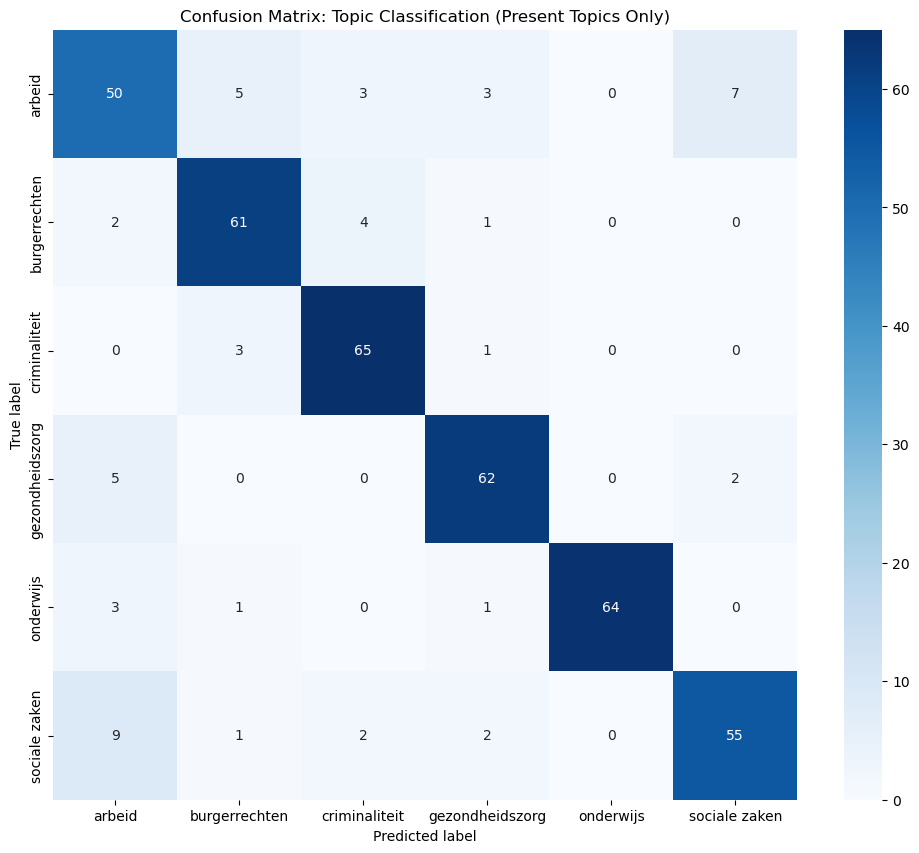

In [22]:
import os
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import classification_report
import numpy as np
from sklearn.preprocessing import LabelEncoder
import pickle

# --- 1. Prepare DataFrame and Encode Labels ---
# matched_df should have columns: 'sentence' and 'topic'
le = LabelEncoder()
train_source['label'] = le.fit_transform(train_source['topic'])

# Split your data (replace with your split method)
# Example:
# train_df = matched_df.sample(frac=0.8, random_state=42)
# val_df = matched_df.drop(train_df.index)

# (If you already have train_df/val_df with the correct 'label' column, continue)

# Build label2topic and topic2label for reference
label2topic = dict(zip(le.transform(le.classes_), le.classes_))
topic2label = dict(zip(le.classes_, le.transform(le.classes_)))
print("label2topic:", label2topic)

with open('slavery-label2topic.pickle', 'wb') as fp:
    pickle.dump(label2topic, fp, protocol=pickle.HIGHEST_PROTOCOL)

with open('slavery-topic2label.pickle', 'wb') as fp:
    pickle.dump(topic2label, fp, protocol=pickle.HIGHEST_PROTOCOL)



# --- 2. Convert to HuggingFace Datasets ---
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

# --- 3. Tokenization ---
MODEL_NAME = "GroNLP/bert-base-dutch-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(batch["sentence"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

# --- 4. Model Setup ---
num_labels = len(label2topic)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

# --- 5. TrainingArguments ---
os.environ["WANDB_DISABLED"] = "true"
training_args = TrainingArguments(
    output_dir="./bertje_policy",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)

def compute_metrics(eval_pred):
    from sklearn.metrics import accuracy_score, f1_score
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted"),
    }

# --- 6. Trainer ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# --- 7. Training ---
trainer.train()

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# After prediction:
eval_results = trainer.predict(val_dataset)
pred_labels = np.argmax(eval_results.predictions, axis=1)
true_labels = eval_results.label_ids

# --- Safe label/name selection for reporting ---
# Only include labels actually present in y_true or y_pred, and that exist in label2topic
unique_labels = sorted(set(np.unique(true_labels)).union(np.unique(pred_labels)))
all_labels = [l for l in unique_labels if l in label2topic]
all_names = [label2topic[l] for l in all_labels]

# Per-class report (always aligned to what's present)
print(classification_report(
    true_labels,
    pred_labels,
    labels=all_labels,
    target_names=all_names,
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=all_labels)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=all_names, yticklabels=all_names, cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix: Topic Classification (Present Topics Only)")
plt.show()

# -- Save your full mappings for future use --
import pickle
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
with open('policy-label2topic.pickle', 'wb') as fp:
    pickle.dump(label2topic, fp, protocol=pickle.HIGHEST_PROTOCOL)
with open('policy-topic2label.pickle', 'wb') as fp:
    pickle.dump(topic2label, fp, protocol=pickle.HIGHEST_PROTOCOL)